Looking at the profile of the sedov shock wave, and compare different dissipation algorithm

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import richio
import dev

In [3]:
!ls /home/hey4/RICH/alice_data/raw/Sedov3DSchaal15

sedov_0		sedov_200.pvtu	sedov_400.h5	sedov_550	sedov_700.pvtu
sedov_0.h5	sedov_250	sedov_400.pvtu	sedov_550.h5	sedov_750
sedov_0.pvtu	sedov_250.h5	sedov_450	sedov_550.pvtu	sedov_750.h5
sedov_100	sedov_250.pvtu	sedov_450.h5	sedov_600	sedov_750.pvtu
sedov_100.h5	sedov_300	sedov_450.pvtu	sedov_600.h5	sedov_800
sedov_100.pvtu	sedov_300.h5	sedov_50	sedov_600.pvtu	sedov_800.h5
sedov_150	sedov_300.pvtu	sedov_50.h5	sedov_650	sedov_800.pvtu
sedov_150.h5	sedov_350	sedov_50.pvtu	sedov_650.h5	sedov_819
sedov_150.pvtu	sedov_350.h5	sedov_500	sedov_650.pvtu	sedov_819.h5
sedov_200	sedov_350.pvtu	sedov_500.h5	sedov_700	sedov_819.pvtu
sedov_200.h5	sedov_400	sedov_500.pvtu	sedov_700.h5


In [4]:
snap = richio.load("/home/hey4/RICH/alice_data/raw/Sedov3DSchaal15/sedov_750.h5")

In [27]:
print(snap.time)

0.07875097571713673 code_time


In [29]:
R = (snap.X**2 + snap.Y**2 + snap.Z**2) ** 0.5
Rho = snap.density
Ediss = snap.dissipation * snap.volume

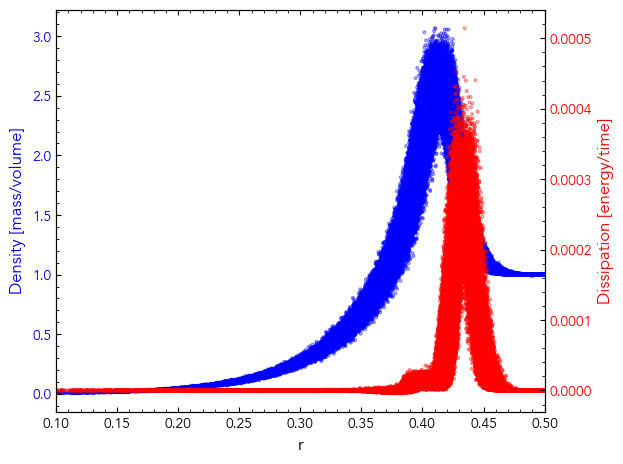

In [30]:
rho_r, r = snap.profile(data="density", weights="volume", res=200)
fig, ax1 = plt.subplots()

ax1.plot(r, rho_r, color="b", label="Density")
ax1.scatter(
    R,#[::100],
    Rho,#[::100],
    s=3,
    marker="o",
    facecolors="none",
    edgecolors="b",
    alpha=0.5,
)
ax1.set_xlabel("r")
ax1.set_ylabel(r"Density [mass/volume]", color="b")
ax1.tick_params(axis="y", labelcolor="b")
ax1.set_xlim(0.1, snap.box[3])

ax2 = ax1.twinx()
# diss_r, r = snap.profile(data=snap.dissipation * snap.volume, res=200)
# ax2.plot(r, diss_r, color="r", label="Dissipation")
ax2.scatter(
    R,#[::100],
    Ediss,#[::100],
    s=3,
    marker="o",
    facecolors="none",
    edgecolors="r",
    alpha=0.5,
)
ax2.set_ylabel(r"Dissipation [energy/time]", color="r")
ax2.tick_params(axis="y", labelcolor="r")

fig.tight_layout()
plt.show()

Analytical profile

In [31]:
# Analytical profile
kappa = 0.49  # for gamma = 1.67
gamma = 5 / 3
rho0 = 1.0 * richio.units.get_unit("Density")
# sie0 = 0.1 * richio.units.get_unit("InternalEnergy")
# P0 = (gamma - 1) * rho0 * sie0
P0 = 1e-4 * richio.units.get_unit("Pressure")
c0 = (gamma * P0 / rho0) ** 0.5

snapv2 = snap.vx**2 + snap.vy**2 + snap.vz**2
E = np.sum(
    snap.sie * snap.density * snap.volume + snap.density * snap.volume * snapv2 / 2
)
t = snap.time

Rsh = (E / kappa / rho0) ** (1 / 5) * t ** (2 / 5)

In [32]:
from scipy.optimize import brentq

# Sedov-Taylor self-similar solution (Landau & Lifshitz, Fluid Mechanics, sec. 106-107).
#
# Dimensionless variables (106.4):  v = 2 r V / (5 t),  rho = rho1 G,  c^2 = 4 r^2 Z / (25 t^2)
# Similarity variable (106.5):      xi = r / R(t)
# We integrate the flow by parametrising everything through V, which runs from
#   V = 1/gamma   at the centre (xi -> 0),   to   V = 2/(gamma+1) at the shock (xi = 1).

# exponents (106.10)
nu1 = -(13 * gamma**2 - 7 * gamma + 12) / ((3 * gamma - 1) * (2 * gamma + 1))
nu2 = 5 * (gamma - 1) / (2 * gamma + 1)
nu3 = 3 / (2 * gamma + 1)
nu4 = -nu1 / (2 - gamma)
nu5 = -2 / (2 - gamma)


def sedov_xi(V):
    """xi(V) from the first relation of (106.10): xi^5 = ... ."""
    A = (0.5 * (gamma + 1) * V) ** (-2)
    B = ((gamma + 1) / (7 - gamma) * (5 - (3 * gamma - 1) * V)) ** nu1
    C = ((gamma + 1) / (gamma - 1) * (gamma * V - 1)) ** nu2
    return (A * B * C) ** 0.2


def sedov_G(V):
    """Reduced density G(V) from (106.10)."""
    return (
        (gamma + 1)
        / (gamma - 1)
        * ((gamma + 1) / (gamma - 1) * (gamma * V - 1)) ** nu3
        * ((gamma + 1) / (7 - gamma) * (5 - (3 * gamma - 1) * V)) ** nu4
        * ((gamma + 1) / (gamma - 1) * (1 - V)) ** nu5
    )


def sedov_Z(V):
    """Reduced sound speed Z(V) from (106.8)."""
    return gamma * (gamma - 1) * (1 - V) * V**2 / (2 * (gamma * V - 1))


# Solve the algebraic equation xi(V) = xi for V at a given radius.
# sedov_xi is monotonic on [1/gamma, 2/(gamma+1)], so brentq is safe.
Vmin, Vmax = 1 / gamma, 2 / (gamma + 1)


def V_of_xi(xi):
    return brentq(lambda V: sedov_xi(V) - xi, Vmin, Vmax + 1e-6)


R = Rsh  # scalar quantity, code_length  (indexing keeps the unyt unit)
tnow = t  # scalar quantity, code_time
rho1 = rho0  # ambient (pre-shock) density, code_mass/code_length**3

# V, G, Z, xi are dimensionless; the physical profiles below carry units through R/t/rho1.
V = Vmin + np.geomspace(
    1e-9, Vmax - Vmin, 400
)  # strictly inside (1/gamma, 2/(gamma+1)]
xi = sedov_xi(V)
G = sedov_G(V)
Z = sedov_Z(V)

r_an = xi * R  # code_length
v_an = 2 * r_an * V / (5 * tnow)  # radial velocity, code_length/code_time
rho_an = rho1 * G  # density
p_an = (
    rho_an * (4 * r_an**2 * Z / (25 * tnow**2)) / gamma
)  # pressure, from c^2 = gamma p / rho

# sanity checks at the shock (strong-shock Rankine-Hugoniot); ratios are dimensionless
vsh = 2 / 5 * R / tnow  # dR/dt
print(f"shock radius R = {R:.4f}, shock speed = {vsh:.4f}")
print(f"sound speed = {c0:.4f}, Mach number = {vsh / c0:.4f}")
print(f"total energy = {E:.4e}")


shock radius R = 0.4173 code_length, shock speed = 2.1197 code_length/code_time
sound speed = 0.0129 code_length/code_time, Mach number = 164.1932 dimensionless
total energy = 1.0001e+00 code_length**2*code_mass/code_time**2


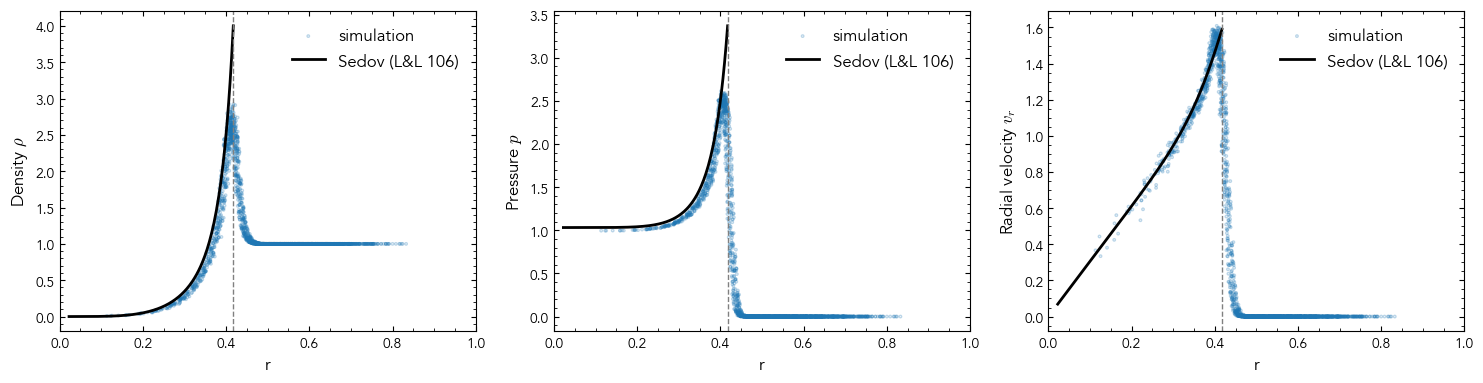

In [33]:
# Compare the analytical Sedov profile with the simulation.
# Radial coordinate and radial velocity of every cell:
r_sim = (snap.X**2 + snap.Y**2 + snap.Z**2) ** 0.5
vr_sim = (snap.vx * snap.X + snap.vy * snap.Y + snap.vz * snap.Z) / r_sim

fields = [
    (rho_an, snap.density, r"Density $\rho$"),
    (p_an, snap.pressure, r"Pressure $p$"),
    (v_an, vr_sim, r"Radial velocity $v_r$"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (an, sim, label) in zip(axes, fields):
    ax.scatter(
        r_sim[::50],
        sim[::50],
        s=3,
        marker="o",
        facecolors="none",
        edgecolors="C0",
        alpha=0.3,
        label="simulation",
    )
    ax.plot(r_an, an, color="k", lw=2, label="Sedov (L&L 106)")
    ax.axvline(R, ls="--", color="gray", lw=1)
    ax.set_xlabel("r")
    ax.set_ylabel(label)
    ax.set_xlim(0, 1.0)
    ax.legend()

fig.tight_layout()
plt.show()


Analytical dissipation

In [34]:
dEdissdt = 0.46 * E / t

In [35]:
print(dEdissdt)

5.84201966592355 code_length**2*code_mass/code_time**3


In [36]:
np.sum(snap.dissipation * snap.volume)  # should be close to dEdissdt

unyt_quantity(2.88904238, 'code_length**2*code_mass/code_time**3')

In [37]:
np.sum(snap.dissipation * snap.volume) / dEdissdt  # should be close to 1

unyt_quantity(0.49452801, '(dimensionless)')

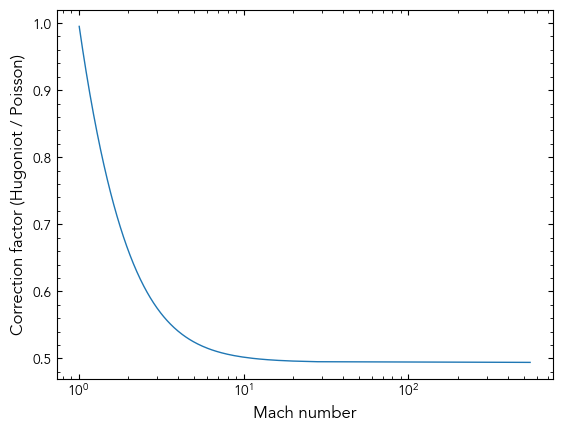

In [38]:
## The analytical curve of the area ratio
rho1 = 1
P1 = 1

R_max = (gamma + 1) / (gamma - 1)
# M_space = np.linspace(1.01, 500, 200)
# R_space = dev.M2R(M_space, gamma=gamma)
R_space = np.linspace(1.01, (1 - 1e-5) * R_max, 200)
M_space = dev.R2M(R_space, gamma=gamma)

A_poisson = []
A_hugoniot = []

for compression_ratio in R_space:
    rho2 = compression_ratio * rho1
    P2 = dev.P_hugoniot(rho2, P_ref=P1, rho_ref=rho1, gamma=gamma)

    v1 = 1.0 / rho1
    v2 = 1.0 / rho2

    # Use a linear spacing for specific volume v
    v_axis = np.linspace(v2, v1, 3000)

    # Calculate pressures along the v_axis
    P_R = P1 + (P2 - P1) * (v_axis - v1) / (v2 - v1)
    P_H = dev.P_hugoniot(1.0 / v_axis, P_ref=P2, rho_ref=rho2, gamma=gamma)
    P_A = dev.P_poisson(1.0 / v_axis, P_ref=P1, rho_ref=rho1, gamma=gamma)

    # Area 1: The "Lens" between Rayleigh and Hugoniot
    A_h = np.trapezoid(P_R - P_H, v_axis)

    # Area 2: The difference between Rayleigh and Adiabat
    A_p = np.trapezoid(P_R - P_A, v_axis)

    A_poisson.append(A_p)
    A_hugoniot.append(A_h)

A_poisson = np.array(A_poisson)
A_hugoniot = np.array(A_hugoniot)
area_ratio = A_hugoniot / A_poisson

plt.plot(M_space, area_ratio)
plt.xlabel("Mach number")
plt.ylabel("Correction factor (Hugoniot / Poisson)")
plt.xscale("log")
# plt.yscale("log")
plt.show()
# From 1 to 0.49 (after M~10)

## Shock finder

In [39]:
import richio.shockfinder as sf

In [40]:
t0 = time.perf_counter()
vor = sf.build_voronoi(snap)
print(f"Built in {time.perf_counter() - t0:.1f} s")

Building Voronoi for 125,000 cells ...


Done.  Mean neighbours/cell: 14.7
Built in 5.2 s


In [41]:
t0 = time.perf_counter()
shock_zone = sf.find_shock_zone(snap, vor)
print(f"{shock_zone.sum():,} shock-zone cells  ({time.perf_counter() - t0:.2f} s)")

32,121 shock-zone cells  (0.06 s)


In [42]:
t0 = time.perf_counter()
result = sf.find_shock_surface(snap, vor, shock_zone)
print(
    f"{result.surface_mask.sum():,} surface cells  ({time.perf_counter() - t0:.2f} s)"
)
print(
    f"Median Mach  T={np.median(result.mach_T):.2f}  P={np.median(result.mach_P):.2f}  rho={np.median(result.mach_rho):.2f}"
)


7,044 surface cells  (0.08 s)
Median Mach  T=165.96  P=135.11  rho=2.33


M_T    n= 7044  finite= 7044  min=129.38  med=165.96  max=203.46
M_P    n= 7044  finite= 7044  min=97.51  med=135.11  max=146.32
M_rho  n= 7044  finite= 7044  min=1.58  med=2.33  max=3.14


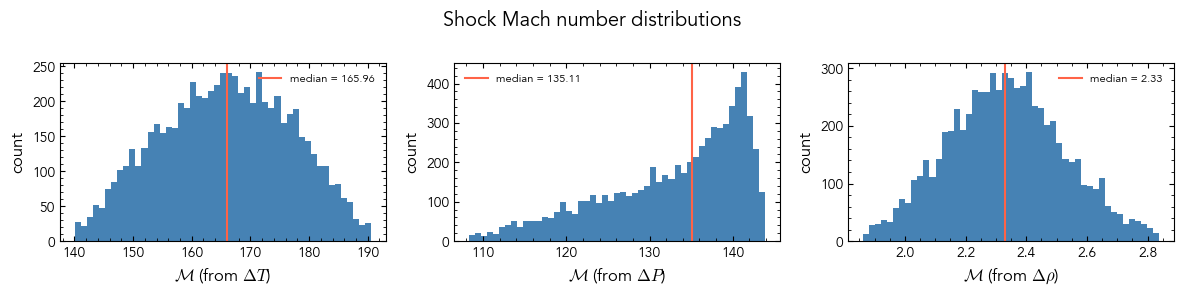

In [43]:
# Quick diagnostics — helps catch unit/scale surprises
for M, label in zip([result.mach_T, result.mach_P, result.mach_rho], ["T", "P", "rho"]):
    finite = M[np.isfinite(M)]
    print(
        f"M_{label:3s}  n={len(M):5d}  finite={len(finite):5d}  "
        f"min={finite.min():.2f}  med={np.median(finite):.2f}  max={finite.max():.2f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, M, label in zip(
    axes, [result.mach_T, result.mach_P, result.mach_rho], ["T", "P", r"\rho"]
):
    finite = M[np.isfinite(M)]
    lo, hi = max(1, np.percentile(finite, 1)), np.percentile(finite, 99)
    bins = np.linspace(lo, hi, 50)
    ax.hist(finite, bins=bins, color="steelblue", edgecolor="none")
    ax.axvline(
        np.median(finite),
        color="tomato",
        lw=1.5,
        label=f"median = {np.median(finite):.2f}",
    )
    ax.set_xlabel(f"$\\mathcal{{M}}$ (from $\\Delta {label}$)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
plt.suptitle("Shock Mach number distributions")
plt.tight_layout()
plt.show()


In [44]:
# calculate dissipation rate by
# 1/2 rho_1 M^3 c_1^3 delta(M)
# or (u2 rho2 - u1 rho1(rho2/rho1)^gamma)*v2 A

In [45]:
def delta(M, gamma):
    R = 1 / ((gamma - 1) / (gamma + 1) + 2 / (gamma + 1) / M**2)
    deltaM = (
        2
        / (gamma * (gamma - 1) * M**2 * R)
        * ((2 * gamma * M**2 - (gamma - 1)) / (gamma + 1) - R**gamma)
    )
    return deltaM

In [46]:
diss_rate_sf = (
    1 / 2
    * rho0
    * result.mach_T**3
    * c0**3
    * (3/4*snap.volume[result.surface_mask]) ** (2 / 3) * np.pi**(1/3)
    * delta(result.mach_T, gamma=gamma)
)
print(f"Total dissipation rate from shock finder = {diss_rate_sf.sum():.4e}")

Total dissipation rate from shock finder = 6.4775e+00 code_length**2*code_mass/code_time**3


In [48]:
shock_surface_sf = ((3 / 4 * snap.volume[result.surface_mask]) ** (2 / 3) * np.pi ** (1 / 3)).sum()
shock_surface_an = 4 * np.pi * R**2
print(f"Shock surface area from shock finder = {shock_surface_sf:.4e}")
print(f"Shock surface area from analytical solution = {shock_surface_an:.4e}")

Shock surface area from shock finder = 2.3405e+00 code_length**2
Shock surface area from analytical solution = 2.1886e+00 code_length**2
